### General Imports:


In [1]:
import os
import gymnasium as gym
from stable_baselines3.ppo import PPO, MlpPolicy
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
from netsim.gym_basic.envs import RMSA_ENV
from netsim.netSimPy.common.allocators import sap_ff
from netsim.netSimPy import *
import numpy as np
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

logging.getLogger("tensorflow").setLevel(logging.FATAL)

/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# FILES AND DIRECTORIES:
__file__ = "[DAGGER] HEURISTIC_RF.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
log_dir = f"./tmp/{file_name}/"
# SIMULATION PARAMS:
EPISODE_LENGTH = 1000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 200000  # 300 Erlangs

networkPaths = "/Users/jbcedeno/Documents/projcts/multiband-gymnasium/networks/nsfnet"
network = Network(
    networkFileName=networkPaths + "/network.json",
    pathsFileName=networkPaths + "/routes.json",
    bitrateFilename=networkPaths + "/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
sim_args = dict(eventsGenerator=generator, network=network)
simulator = NetworkSimulator(**sim_args)
# Building the environment:
env_args = dict(
    simulator=simulator,
    episode_length=EPISODE_LENGTH,
    j=N_BLOCKS,
    n_paths=N_PATHS,
    allocator=sap_ff(3),
)

env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir)
eval_env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir + "eval_env")

# mArgs = dict(
#     learning_rate=0.0005,
#     gamma=0.9,
# )
# expert = PPO(MlpPolicy, env, verbose=0, seed=3, **mArgs)
# train_model = expert.learn(total_timesteps=1)

# best_model_dir = f"./tmp/ACTION_RMSA_ENV/best_smooth_model"
# expert = PPO.load(best_model_dir)

In [16]:
from sklearn import tree
from netsim.explainable.common.dagger import Dagger
from netsim.explainable.common.beta import linear_beta
from netsim.netSimPy.common.heuristic_models import FirstFitModel

FEATURE_IDXS = [28, 41]
USE_FEATURE_SUBSET = False

n_rounds = 2
beta_func = linear_beta(1, 0, n_rounds)

if USE_FEATURE_SUBSET:
    selector = FunctionTransformer(
        lambda X: np.asarray(X)[:, FEATURE_IDXS], validate=False
    )
    student = Pipeline(
        [
            ("select", selector),
            ("clf", tree.DecisionTreeClassifier(max_depth=2, criterion="entropy")),
        ]
    )
else:
    student = tree.DecisionTreeClassifier(max_depth=2, criterion="entropy")

expert = FirstFitModel()

dagger_trainer = Dagger(expert, student, env, beta_func)
model = dagger_trainer.train(n_rounds, timesteps_by_round=10000, n_evaluations=100)

#
#

Starting round 1
Sampling new trajectories for round: {1} 
1.0 [[91  0  0]
 [ 0  4  0]
 [ 0  0  5]]
Starting round 2
Sampling new trajectories for round: 2 
Fitting student for round: 2 
1.0 [[97  0]
 [ 0  3]]


### features importance


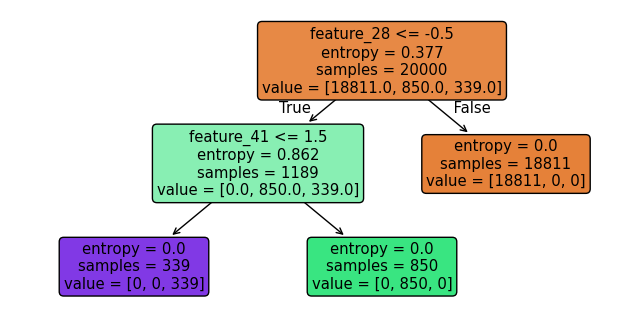

In [17]:
# Mostrar el grafo:
tree_output_dir = f"./plots/{__file__}/decision_tree/"
os.makedirs(tree_output_dir, exist_ok=True)

tree_model = student.named_steps["clf"] if hasattr(student, "named_steps") else student
feature_labels = (
    FEATURE_IDXS if USE_FEATURE_SUBSET else list(range(tree_model.n_features_in_))
)
feature_names = [f"feature_{idx}" for idx in feature_labels]
plt.figure(figsize=(8, 4))
tree.plot_tree(tree_model, filled=True, rounded=True, feature_names=feature_names)
plt.savefig(tree_output_dir + "decision_tree.png", bbox_inches="tight")
plt.show()

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.86384568 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.13615432
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        ]


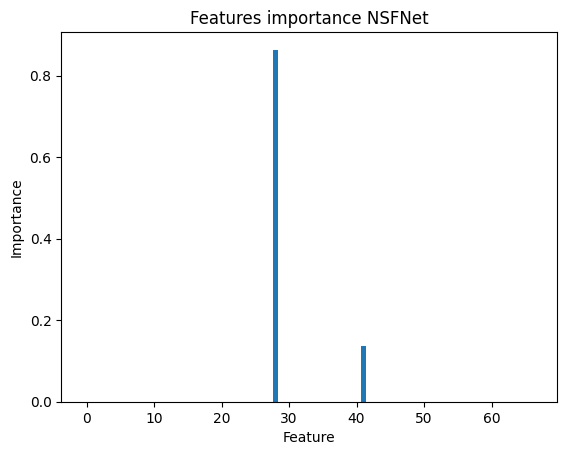

In [18]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

tree_model = student.named_steps["clf"] if hasattr(student, "named_steps") else student
importances_sk = tree_model.feature_importances_
feature_labels = (
    FEATURE_IDXS if USE_FEATURE_SUBSET else list(range(tree_model.n_features_in_))
)
importance = pd.DataFrame(importances_sk, index=feature_labels)
# importance = pd.DataFrame(importances_sk)
print(importances_sk)
plt.figure()
plt.bar(feature_labels, importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()